In [ ]:
!pip install -q segmentation-models-pytorch albumentations timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# ====================================
# CONFIG
# ====================================

IMAGE_DIR = "/content/drive/MyDrive/augmented/images"
MASK_DIR  = "/content/drive/MyDrive/augmented/masks"

IMG_SIZE = 512
BATCH_SIZE = 4
EPOCHS = 75
LR = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ====================================
# DATASET
# ====================================

files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".png")
])

train_files, val_files = train_test_split(
    files,
    test_size=0.15,
    random_state=42
)

print("Train:", len(train_files))
print("Val:", len(val_files))

# ====================================
# TRANSFORMS
# ====================================

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

# ====================================
# DATASET CLASS
# ====================================

class LakeDataset(Dataset):

    def __init__(self, files, transform):

        self.files = files
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]

        image = cv2.imread(
            os.path.join(IMAGE_DIR,file)
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(
            os.path.join(MASK_DIR,file),
            0
        )

        mask = (mask > 0).astype(np.float32)

        aug = self.transform(
            image=image,
            mask=mask
        )

        return aug["image"], aug["mask"]

# ====================================
# LOADERS
# ====================================

train_ds = LakeDataset(
    train_files,
    train_tf
)

val_ds = LakeDataset(
    val_files,
    val_tf
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# ====================================
# MODEL
# ====================================

model = smp.DeepLabV3Plus(
    encoder_name="efficientnet-b4",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)

# ====================================
# LOSS
# ====================================

bce_loss = nn.BCEWithLogitsLoss()

tversky_loss = smp.losses.TverskyLoss(
    mode="binary",
    alpha=0.7,
    beta=0.3
)

def criterion(logits, targets):

    targets = targets.unsqueeze(1)

    bce = bce_loss(
        logits,
        targets
    )

    tv = tversky_loss(
        logits,
        targets
    )

    return 0.5*bce + 0.5*tv

# ====================================
# OPTIMIZER
# ====================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# ====================================
# TRAINING
# ====================================

best_loss = 999

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0

    for images,masks in tqdm(train_loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            masks
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ------------------

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for images,masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(images)

            loss = criterion(
                logits,
                masks
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train {train_loss:.4f} | "
        f"Val {val_loss:.4f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/best_glacial_model1.pth"
        )

        print("Saved Best Model")

print("Training Complete")

Train: 299
Val: 53


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

100%|██████████| 75/75 [01:14<00:00,  1.00it/s]


...

Epoch 73/75 | Train 0.0231 | Val 0.0261


100%|██████████| 75/75 [00:34<00:00,  2.16it/s]


Epoch 74/75 | Train 0.0229 | Val 0.0259
Saved Best Model


100%|██████████| 75/75 [00:35<00:00,  2.13it/s]


Epoch 75/75 | Train 0.0237 | Val 0.0260
Training Complete


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    cohen_kappa_score,
    confusion_matrix
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_glacial_model1.pth"
    )
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images,masks in val_loader:

        images = images.to(DEVICE)

        preds = torch.sigmoid(
            model(images)
        )

        preds = (
            preds > 0.5
        ).cpu().numpy()

        masks = masks.numpy()

        y_true.extend(
            masks.flatten()
        )

        y_pred.extend(
            preds.flatten()
        )

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

iou = jaccard_score(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n===== RESULTS =====")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)
print("IoU      :", iou)
print("Kappa    :", kappa)

print("\nConfusion Matrix")
print(cm)


===== RESULTS =====
Accuracy : 0.9968366802863355
Precision: 0.9846990679968496
Recall   : 0.9454501055550304
F1       : 0.9646755292642544
IoU      : 0.9317615458067121
Kappa    : 0.9630204474648963

Confusion Matrix
[[13249567     9325]
 [   34625   600115]]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.DeepLabV3Plus(
    encoder_name="efficientnet-b4",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(DEVICE)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_glacial_model1.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Model Loaded")

Model Loaded


In [ ]:
from google.colab import files

uploaded = files.upload()

IMAGE_PATH = list(uploaded.keys())[0]

print("Uploaded:", IMAGE_PATH)

Saving 33.png to 33.png
Uploaded: 33.png


Lake Count      : 11
Total Lake Area : 4564.0
Largest Lake    : 1761.5


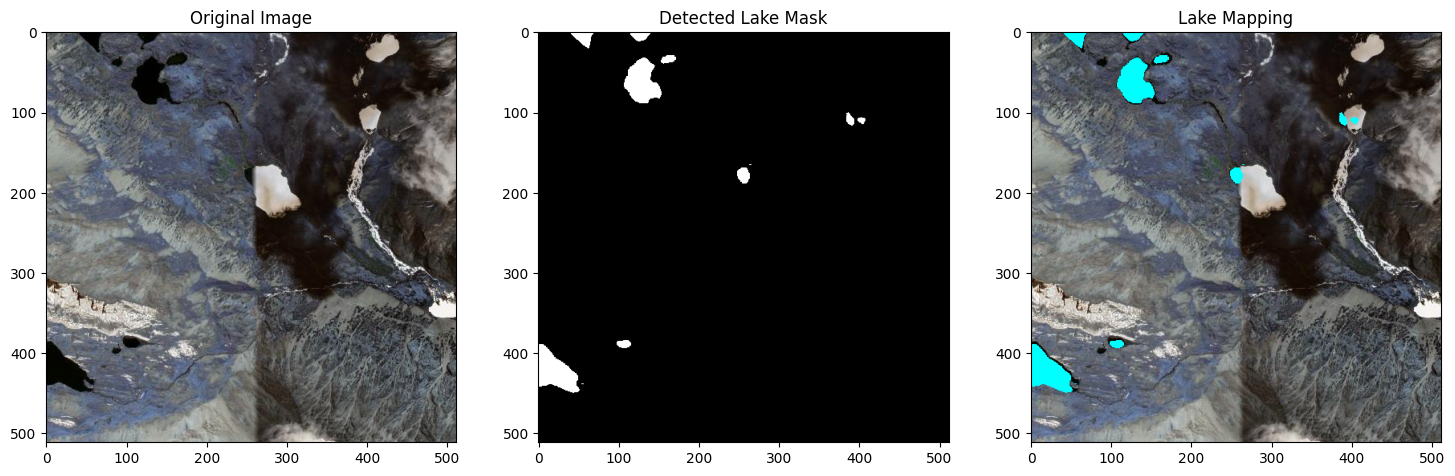

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 768

transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

# --------------------------
# Read image
# --------------------------

img = cv2.imread(IMAGE_PATH)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

h,w = img_rgb.shape[:2]

# --------------------------
# Preprocess
# --------------------------

tensor = transform(
    image=img_rgb
)["image"]

tensor = tensor.unsqueeze(0).to(DEVICE)

# --------------------------
# Predict
# --------------------------

with torch.no_grad():

    pred = torch.sigmoid(
        model(tensor)
    )

pred = pred.squeeze().cpu().numpy()

pred = (pred > 0.5).astype(np.uint8)

# --------------------------
# Resize back
# --------------------------

mask = cv2.resize(
    pred,
    (w,h),
    interpolation=cv2.INTER_NEAREST
)

# --------------------------
# Lake Statistics
# --------------------------

contours,_ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

lake_count = len(contours)

areas = [
    cv2.contourArea(c)
    for c in contours
]

total_area = sum(areas)

largest_area = (
    max(areas)
    if len(areas)>0
    else 0
)

# --------------------------
# Overlay
# --------------------------

overlay = img_rgb.copy()

overlay[mask==1] = [0,255,255]

# --------------------------
# Results
# --------------------------

print("Lake Count      :", lake_count)
print("Total Lake Area :", total_area)
print("Largest Lake    :", largest_area)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(mask,cmap="gray")
plt.title("Detected Lake Mask")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Lake Mapping")

plt.show()

In [ ]:
cv2.imwrite(
    "lake_mask.png",
    mask*255
)

cv2.imwrite(
    "lake_overlay.png",
    cv2.cvtColor(
        overlay,
        cv2.COLOR_RGB2BGR
    )
)

print("Saved:")
print("lake_mask.png")
print("lake_overlay.png")

Saved:
lake_mask.png
lake_overlay.png
